In [1]:
import pandas as pd
import numpy as np

from pathlib import Path
from datetime import datetime
import logging
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    confusion_matrix,
    brier_score_loss
)

import matplotlib.pyplot as plt

RANDOM_SEED = 42

print("Libraries imported")

Libraries imported


In [2]:
# Load the original panel
DATA_PATH = Path("final_panel.csv")

df_raw = pd.read_csv(
    DATA_PATH,
    dtype={
        "gvkey": "string",
        "cik": "string",
        "cusip": "string",
        "tic": "string"
    },
    parse_dates=["datadate", "INFO_DATE"]
)

# Working copy
df = df_raw.copy()

print(f"Loaded: {len(df_raw):,} rows, {len(df_raw.columns)} columns")
print(f"Unique firms: {df_raw['gvkey'].nunique():,}")
print(f"Fiscal years: {df_raw['fyear'].min()}–{df_raw['fyear'].max()}")
print(f"First 10 columns: {df_raw.columns[:10].tolist()}")

# Validate the firm-year key
assert df_raw[["gvkey", "fyear"]].notna().all().all(), \
    "Missing firm identifiers or fiscal years."

assert not df_raw.duplicated(["gvkey", "fyear"]).any(), \
    "Duplicate firm-year observations found."

print("Firm-year identifiers validated.")

Loaded: 83,726 rows, 75 columns
Unique firms: 12,275
Fiscal years: 2011–2022
First 10 columns: ['gvkey', 'cik', 'conm', 'tic', 'cusip', 'fyear', 'datadate', 'INFO_DATE', 'costat', 'SIC']
Firm-year identifiers validated.


In [3]:
# TASK 1.1 — Apply the auopic label filter

print("TASK 1.1")

# Original label distribution, including missing labels
print("\nOriginal label counts:")
print(df_raw["auopic"].value_counts(dropna=False).sort_index())

# Keep only assessed firm-years:
# 1 = effective internal controls
# 2 = adverse opinion / material weakness
keep_mask = df_raw["auopic"].isin([1, 2])

df = df_raw.loc[keep_mask].copy()
df["auopic"] = df["auopic"].astype(int)

# Document exclusions
exclusion_counts = pd.Series({
    "Code 0": int(df_raw["auopic"].eq(0).sum()),
    "Codes 3 and 4": int(df_raw["auopic"].isin([3, 4]).sum()),
    "Missing labels": int(df_raw["auopic"].isna().sum()),
    "Other nonmissing codes": int(
        (
            df_raw["auopic"].notna()
            & ~df_raw["auopic"].isin([0, 1, 2, 3, 4])
        ).sum()
    )
})

print("\nExcluded rows:")
print(exclusion_counts)

assert not df.empty, "No eligible observations remain."
assert df["auopic"].isin([1, 2]).all(), "Unexpected labels remain."
assert exclusion_counts.sum() == len(df_raw) - len(df), \
    "Exclusion counts do not reconcile."

n_effective = int(df["auopic"].eq(1).sum())
n_adverse = int(df["auopic"].eq(2).sum())
base_rate = n_adverse / len(df)

print(f"\nOriginal rows: {len(df_raw):,}")
print(f"Excluded rows: {len(df_raw) - len(df):,}")
print(f"Retained rows: {len(df):,}")
print(f"Retained firms: {df['gvkey'].nunique():,}")
print(f"Effective controls: {n_effective:,}")
print(f"Adverse opinions: {n_adverse:,}")
print(f"Adverse rate among assessed firm-years: {base_rate:.2%}")

# Illustrate the effect of incorrectly treating code 0 as negative.
# Codes 3, 4 and missing labels remain excluded from this comparison.
incorrect_denominator = int(df_raw["auopic"].isin([0, 1, 2]).sum())
incorrect_rate = n_adverse / incorrect_denominator

print(
    f"\nIf code 0 were incorrectly treated as negative: "
    f"{incorrect_rate:.2%}"
)
print("Task 1.1 complete.")

TASK 1.1

Original label counts:
auopic
0.0    40802
1.0    40719
2.0     2009
3.0        4
4.0        3
NaN      189
Name: count, dtype: int64

Excluded rows:
Code 0                    40802
Codes 3 and 4                 7
Missing labels              189
Other nonmissing codes        0
dtype: int64

Original rows: 83,726
Excluded rows: 40,998
Retained rows: 42,728
Retained firms: 6,187
Effective controls: 40,719
Adverse opinions: 2,009
Adverse rate among assessed firm-years: 4.70%

If code 0 were incorrectly treated as negative: 2.41%
Task 1.1 complete.


In [5]:
# TASK 1.2 — Label timing
print("TASK 1.2: Label timing")
print("Decision: Use fiscal-year t features to predict fiscal-year t+1 auopic.")

# Rebuild from the original panel so this cell can be rerun safely.
# Current policy: both predictor and outcome years must be assessed.
features_t = df_raw.loc[
    df_raw["auopic"].isin([1, 2])
].copy()

features_t["auopic"] = features_t["auopic"].astype(int)
features_t["feature_year"] = features_t["fyear"].astype(int)
features_t["outcome_year"] = features_t["feature_year"] + 1

# Assumed predictor availability from the project plan
features_t["prediction_date"] = features_t["INFO_DATE"]

# Eligible outcome records
outcomes = df_raw.loc[
    df_raw["auopic"].isin([1, 2]),
    ["gvkey", "fyear", "auopic", "datadate", "INFO_DATE"]
].copy()

outcomes = outcomes.rename(columns={
    "fyear": "outcome_year",
    "auopic": "auopic_outcome",
    "datadate": "outcome_datadate",
    "INFO_DATE": "outcome_info_date"
})

# Match the SAME firm and EXACTLY fiscal year t+1
matched = features_t.merge(
    outcomes,
    on=["gvkey", "outcome_year"],
    how="left",
    validate="one_to_one",
    indicator=True
)

n_before = len(features_t)
n_unmatched = int(matched["_merge"].eq("left_only").sum())

df = (
    matched.loc[matched["_merge"].eq("both")]
    .drop(columns="_merge")
    .sort_values(["gvkey", "feature_year"])
    .reset_index(drop=True)
)

df["auopic_outcome"] = df["auopic_outcome"].astype(int)

# Binary target: 0 = effective; 1 = adverse opinion
df["target"] = df["auopic_outcome"].eq(2).astype(int)

# Validate target alignment and assumed availability dates
assert not df.empty, "No eligible consecutive-year pairs found."
assert df["outcome_year"].eq(df["feature_year"] + 1).all(), \
    "Found an outcome that is not exactly year t+1."
assert df["auopic_outcome"].isin([1, 2]).all(), \
    "Unexpected outcome labels."

assert df[
    ["prediction_date", "outcome_info_date"]
].notna().all().all(), "Missing timing dates."

assert df["prediction_date"].lt(df["outcome_info_date"]).all(), \
    "Predictor availability must precede the outcome INFO_DATE."

# Record the decision for the later model card
timing_decision = {
    "task": "1.2",
    "design": "Fiscal-year t features predict fiscal-year t+1 auopic",
    "matching": "Exact gvkey and fiscal-year match",
    "sample_policy": "Both years restricted to auopic codes 1 and 2",
    "predictor_availability": "INFO_DATE supplied in the panel",
    "limitation": (
        "INFO_DATE is an assumed availability date, "
        "not a verified auditor-report publication date."
    )
}

print(f"\nEligible predictor-year rows: {n_before:,}")
print(f"No eligible exact next-year outcome: {n_unmatched:,}")
print(f"Retained consecutive-year pairs: {len(df):,}")
print(f"Adverse next-year outcomes: {df['target'].sum():,}")
print(f"Next-year adverse rate: {df['target'].mean():.2%}")

print("\nExample year matches:")
print(df[
    ["gvkey", "feature_year", "outcome_year",
     "prediction_date", "auopic_outcome"]
].head().to_string(index=False))

print("\nTask 1.2 timing decision recorded in timing_decision.")

TASK 1.2: Label timing
Decision: Use fiscal-year t features to predict fiscal-year t+1 auopic.

Eligible predictor-year rows: 42,728
No eligible exact next-year outcome: 6,482
Retained consecutive-year pairs: 36,246
Adverse next-year outcomes: 1,433
Next-year adverse rate: 3.95%

Example year matches:
 gvkey  feature_year  outcome_year prediction_date  auopic_outcome
001004          2011          2012      2012-08-31               1
001004          2012          2013      2013-08-31               1
001004          2013          2014      2014-08-31               1
001004          2014          2015      2015-08-31               1
001004          2015          2016      2016-08-31               1

Task 1.2 timing decision recorded in timing_decision.


In [9]:
# TASK 1.3 — Build the financial feature table

print("TASK 1.3: Build feature table")

# Use the original, unsuffixed financial columns.
# Any additional outlier treatment will be fitted on training data only.
feature_cols = [
    "LNEMP", "LNTA", "LNSALE", "LNTI", "IntanTA", "InvCA", "CapInt",
    "TobinQ", "RET1Y", "ROA", "ROE", "GPM", "CURR_RATIO", "AT_TURN",
    "INV_TURN", "DPR", "PTB", "PE", "cfsale"
]

required_cols = feature_cols[:-1] + ["oibdp", "sale", "target"]
missing_cols = [col for col in required_cols if col not in df.columns]

assert not missing_cols, f"Required columns are missing: {missing_cols}"

# Compute CFsale; zero sales cannot produce a valid ratio.
numerator = pd.to_numeric(df["oibdp"], errors="raise")
denominator = pd.to_numeric(df["sale"], errors="raise")

df["cfsale"] = numerator / denominator.replace(0, np.nan)

# Convert features to numeric and replace infinity with missing values.
df[feature_cols] = (
    df[feature_cols]
    .apply(pd.to_numeric, errors="raise")
    .replace([np.inf, -np.inf], np.nan)
)

# Report genuinely usable CFsale values
n_cfsale = int(df["cfsale"].notna().sum())

print(f"\nZero-sales rows: {denominator.eq(0).sum():,}")
print(
    f"Finite CFsale values: {n_cfsale:,} / {len(df):,} "
    f"({n_cfsale / len(df):.2%})"
)

# Diagnostic summary; this does not determine preprocessing rules.
missingness = pd.DataFrame({
    "missing_rows": df[feature_cols].isna().sum(),
    "missing_percent": df[feature_cols].isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

print("\nFeature missingness before imputation:")
print(missingness.round(2).to_string())

# Record the feature-handling decision for the model card.
feature_decision = {
    "task": "1.3",
    "financial_features": feature_cols.copy(),
    "column_version": "Original unsuffixed columns",
    "cfsale_formula": "oibdp / sale; zero denominator treated as missing",
    "nonfinite_values": "Converted to missing",
    "INV_TURN_and_DPR": (
        "Retained. Missingness may be structural; "
        "use training-fitted median imputation with missing indicators."
    ),
    "imputation": "Deferred until after temporal split",
    "outlier_treatment": "Any additional rules fitted on training data only"
}

assert not np.isinf(
    df[feature_cols].to_numpy(dtype=float)
).any(), "Infinite feature values remain."

assert df["target"].isin([0, 1]).all(), "Unexpected target values."

print(f"\nFinancial features: {len(feature_cols)}")
print(f"Firm-year pairs retained: {len(df):,}")
print("Missing values remain for training-only imputation.")
print("Task 1.3 feature decision recorded in feature_decision.")

TASK 1.3: Build feature table

Zero-sales rows: 426
Finite CFsale values: 34,186 / 36,246 (94.32%)

Feature missingness before imputation:
            missing_rows  missing_percent
INV_TURN           10372            28.62
DPR                 9065            25.01
InvCA               8659            23.89
CURR_RATIO          8295            22.89
CapInt              2511             6.93
PTB                 2354             6.49
cfsale              2060             5.68
ROA                 1751             4.83
ROE                 1599             4.41
RET1Y               1031             2.84
PE                   911             2.51
TobinQ               808             2.23
LNEMP                583             1.61
LNTI                 578             1.59
IntanTA              528             1.46
GPM                  452             1.25
AT_TURN              124             0.34
LNSALE                26             0.07
LNTA                   0             0.00

Financial features: 

In [10]:
# Save the modelling panel before splitting and imputation
output_dir = Path("data")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "modelling_panel.csv"

df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"  - {len(df):,} firm-year pairs")
print(f"  - {len(feature_cols)} financial features")
print("  - Includes identifiers, timing columns and target")
print("  - Missing feature values retained for training-only imputation")

Saved: data/modelling_panel.csv
  - 36,246 firm-year pairs
  - 19 financial features
  - Includes identifiers, timing columns and target
  - Missing feature values retained for training-only imputation


In [11]:
# TASK 1.4 — Temporal train / validation / test split

print("TASK 1.4: Temporal split")

df = df.sort_values(
    ["prediction_date", "gvkey"]
).reset_index(drop=True)

# Fixed outcome-year periods
train_candidates = df.loc[df["outcome_year"] <= 2015].copy()

validation_candidates = df.loc[
    df["outcome_year"].between(2016, 2017)
].copy()

X_test = df.loc[
    df["outcome_year"].between(2018, 2022)
].copy()

assert not train_candidates.empty, "Training period is empty."
assert not validation_candidates.empty, "Validation period is empty."
assert not X_test.empty, "Test period is empty."

# Outcome INFO_DATE is an availability proxy, not a verified report date.
# Earlier labels must be available before the next period's first forecast.
test_start_date = X_test["prediction_date"].min()

X_val = validation_candidates.loc[
    validation_candidates["outcome_info_date"] < test_start_date
].copy()

assert not X_val.empty, "Validation period is empty after timing exclusions."

validation_start_date = X_val["prediction_date"].min()

X_train = train_candidates.loc[
    train_candidates["outcome_info_date"] < validation_start_date
].copy()

assert not X_train.empty, "Training period is empty after timing exclusions."

# Verify chronology under the panel's INFO_DATE assumption
assert (
    X_train["outcome_info_date"].max()
    < X_val["prediction_date"].min()
), "Training labels overlap validation prediction dates."

assert (
    X_val["outcome_info_date"].max()
    < X_test["prediction_date"].min()
), "Validation labels overlap test prediction dates."

# Both classes are needed for fitting and ROC-AUC evaluation
for name, subset in [
    ("Train", X_train),
    ("Validation", X_val),
    ("Test", X_test)
]:
    assert subset["target"].nunique() == 2, \
        f"{name} does not contain both target classes."

    print(f"\n{name}:")
    print(f"  Rows: {len(subset):,}")
    print(
        f"  Feature years: "
        f"{subset['feature_year'].min()}–"
        f"{subset['feature_year'].max()}"
    )
    print(
        f"  Outcome years: "
        f"{subset['outcome_year'].min()}–"
        f"{subset['outcome_year'].max()}"
    )
    print(
        f"  Prediction dates: "
        f"{subset['prediction_date'].min().date()} to "
        f"{subset['prediction_date'].max().date()}"
    )
    print(f"  Adverse outcomes: {subset['target'].sum():,}")
    print(f"  Adverse rate: {subset['target'].mean():.2%}")

print("\nTiming exclusions:")
print(f"  Training: {len(train_candidates) - len(X_train):,}")
print(f"  Validation: {len(validation_candidates) - len(X_val):,}")

split_decision = {
    "task": "1.4",
    "train_outcome_years": "2012–2015, subject to timing exclusions",
    "validation_outcome_years": "2016–2017, subject to timing exclusions",
    "test_outcome_years": "2018–2022",
    "timing_rule": (
        "Earlier-period outcome INFO_DATE must precede "
        "the next period's earliest prediction_date."
    ),
    "validation_use": "Model selection and probability calibration",
    "test_use": "Final evaluation after model selection",
    "limitation": "Availability checks use the panel's INFO_DATE proxy"
}

print("\nTask 1.4 split decision recorded in split_decision.")

TASK 1.4: Temporal split

Train:
  Rows: 10,646
  Feature years: 2011–2013
  Outcome years: 2012–2014
  Prediction dates: 2011-09-30 to 2014-08-31
  Adverse outcomes: 373
  Adverse rate: 3.50%

Validation:
  Rows: 3,365
  Feature years: 2015–2015
  Outcome years: 2016–2016
  Prediction dates: 2015-09-30 to 2016-08-31
  Adverse outcomes: 167
  Adverse rate: 4.96%

Test:
  Rows: 15,536
  Feature years: 2017–2021
  Outcome years: 2018–2022
  Prediction dates: 2017-09-30 to 2022-08-31
  Adverse outcomes: 628
  Adverse rate: 4.04%

Timing exclusions:
  Training: 3,446
  Validation: 3,253

Task 1.4 split decision recorded in split_decision.


In [12]:
# TASK 1.5A — Train the logistic regression baseline

print("TASK 1.5A: Train logistic baseline")

# Select predictors and the binary target created in Task 1.2
X_train_feat = X_train[feature_cols].copy()
y_train = X_train["target"].copy()

X_val_feat = X_val[feature_cols].copy()
y_val = X_val["target"].copy()

X_test_feat = X_test[feature_cols].copy()
y_test = X_test["target"].copy()

# Confirm every feature has at least one observed training value
empty_features = X_train_feat.columns[
    X_train_feat.isna().all()
].tolist()

assert not empty_features, \
    f"Features entirely missing in training: {empty_features}"

print(
    f"\nTraining: {len(X_train_feat):,} rows, "
    f"{len(feature_cols)} financial features"
)
print(
    f"Adverse outcomes: {y_train.sum():,} "
    f"({y_train.mean():.2%})"
)
print(
    f"Missing training entries: "
    f"{X_train_feat.isna().sum().sum():,}"
)

# The pipeline learns all preprocessing from the training set.
logistic_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            random_state=RANDOM_SEED,
            max_iter=5000,
            class_weight=None
        )
    )
])

logistic_pipeline.fit(X_train_feat, y_train)

print("\nLogistic baseline trained.")

# Include names for the missing-value indicators
transformed_names = (
    logistic_pipeline.named_steps["imputer"]
    .get_feature_names_out(feature_cols)
)

coefficients = (
    logistic_pipeline.named_steps["classifier"].coef_[0]
)

coefficient_table = pd.DataFrame({
    "feature": transformed_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
}).sort_values("abs_coefficient", ascending=False)

print("\nTop 10 coefficients by absolute magnitude:")
print(coefficient_table.head(10).to_string(index=False))

print(
    f"\nInputs after adding missing indicators: "
    f"{len(transformed_names)}"
)
print("Validation and test data have not been used to fit the pipeline.")

TASK 1.5A: Train logistic baseline

Training: 10,646 rows, 19 financial features
Adverse outcomes: 373 (3.50%)
Missing training entries: 14,660

Logistic baseline trained.

Top 10 coefficients by absolute magnitude:
                  feature  coefficient  abs_coefficient
     missingindicator_ROA    -0.649706         0.649706
                      PTB    -0.615101         0.615101
  missingindicator_cfsale    -0.542322         0.542322
                 INV_TURN    -0.452737         0.452737
                  AT_TURN     0.414613         0.414613
missingindicator_INV_TURN    -0.317124         0.317124
                      GPM     0.315656         0.315656
                     LNTI    -0.305082         0.305082
     missingindicator_DPR     0.295084         0.295084
                      ROA    -0.252371         0.252371

Inputs after adding missing indicators: 37
Validation and test data have not been used to fit the pipeline.


TASK 1.5B: Logistic baseline validation

Validation rows: 3,365
Observed adverse rate: 4.96%
Mean predicted probability: 3.55%
ROC-AUC: 0.6202
PR-AUC (trapezoidal): 0.0755
Brier score: 0.0471
Constant-probability Brier score: 0.0474


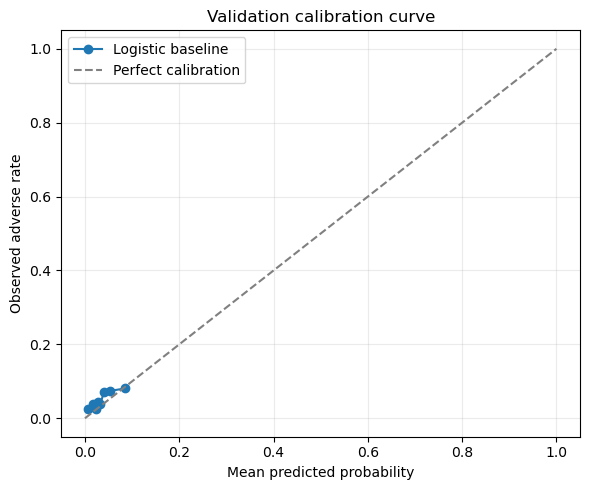

In [15]:
# TASK 1.5B — Evaluate the logistic baseline on validation data

print("TASK 1.5B: Logistic baseline validation")

# The fitted pipeline applies training imputation and scaling automatically.
val_proba = logistic_pipeline.predict_proba(X_val_feat)[:, 1]

val_roc_auc = roc_auc_score(y_val, val_proba)

precision, recall, _ = precision_recall_curve(y_val, val_proba)
val_pr_auc = auc(recall, precision)

val_brier = brier_score_loss(y_val, val_proba)

# Constant-probability benchmark using the training adverse rate
baseline_proba = np.full(len(y_val), y_train.mean())
baseline_brier = brier_score_loss(y_val, baseline_proba)

print(f"\nValidation rows: {len(y_val):,}")
print(f"Observed adverse rate: {y_val.mean():.2%}")
print(f"Mean predicted probability: {val_proba.mean():.2%}")
print(f"ROC-AUC: {val_roc_auc:.4f}")
print(f"PR-AUC (trapezoidal): {val_pr_auc:.4f}")
print(f"Brier score: {val_brier:.4f}")
print(f"Constant-probability Brier score: {baseline_brier:.4f}")

# Calibration diagnostic
observed_rate, predicted_rate = calibration_curve(
    y_val,
    val_proba,
    n_bins=8,
    strategy="quantile"
)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    predicted_rate,
    observed_rate,
    marker="o",
    label="Logistic baseline"
)
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed adverse rate")
ax.set_title("Validation calibration curve")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [16]:
# Save logistic baseline calibration results
results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

# Save the calibration plot from Task 1.5B
plot_path = results_dir / "logistic_validation_calibration.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")

# Save the points plotted on the calibration curve
calibration_points = pd.DataFrame({
    "mean_predicted_probability": predicted_rate,
    "observed_adverse_rate": observed_rate
})

points_path = results_dir / "logistic_validation_calibration_points.csv"
calibration_points.to_csv(points_path, index=False)

# Save validation metrics
calibration_metrics = pd.DataFrame([{
    "model": "Logistic regression",
    "split": "Validation",
    "n_rows": len(y_val),
    "observed_adverse_rate": y_val.mean(),
    "mean_predicted_probability": val_proba.mean(),
    "roc_auc": val_roc_auc,
    "pr_auc_trapezoidal": val_pr_auc,
    "brier_score": val_brier,
    "constant_probability_brier_score": baseline_brier,
    "calibration_bins_requested": 8,
    "bin_strategy": "quantile"
}])

metrics_path = results_dir / "logistic_validation_metrics.csv"
calibration_metrics.to_csv(metrics_path, index=False)

print("Saved files:")
for saved_file in [plot_path, points_path, metrics_path]:
    print(saved_file.resolve())

Saved files:
/Users/jessica/Desktop/ADV ML Group work/results/logistic_validation_calibration.png
/Users/jessica/Desktop/ADV ML Group work/results/logistic_validation_calibration_points.csv
/Users/jessica/Desktop/ADV ML Group work/results/logistic_validation_metrics.csv


In [22]:
# TASK 1.5C — Train and validate Random Forest
from sklearn.ensemble import RandomForestClassifier

print("TASK 1.5C: Random Forest comparison")

rf_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median", add_indicator=True)
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=10,
            max_features="sqrt",
            class_weight=None,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
    )
])

rf_pipeline.fit(X_train_feat, y_train)

rf_val_proba = rf_pipeline.predict_proba(X_val_feat)[:, 1]

rf_precision, rf_recall, _ = precision_recall_curve(
    y_val, rf_val_proba
)

validation_comparison = pd.DataFrame([
    {
        "model": "Logistic regression",
        "ROC_AUC": val_roc_auc,
        "PR_AUC": val_pr_auc,
        "Brier": val_brier,
        "mean_probability": val_proba.mean()
    },
    {
        "model": "Random Forest",
        "ROC_AUC": roc_auc_score(y_val, rf_val_proba),
        "PR_AUC": auc(rf_recall, rf_precision),
        "Brier": brier_score_loss(y_val, rf_val_proba),
        "mean_probability": rf_val_proba.mean()
    }
])

print("\nValidation comparison:")
print(validation_comparison.round(4).to_string(index=False))
print(f"\nObserved validation adverse rate: {y_val.mean():.2%}")
print("Test set remains reserved for final evaluation.")

TASK 1.5C: Random Forest comparison

Validation comparison:
              model  ROC_AUC  PR_AUC  Brier  mean_probability
Logistic regression   0.6202  0.0755 0.0471            0.0355
      Random Forest   0.6824  0.1133 0.0461            0.0386

Observed validation adverse rate: 4.96%
Test set remains reserved for final evaluation.


In [23]:
# Save logistic baseline calibration results
results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

# Save the calibration plot from Task 1.5B
plot_path = results_dir / "logistic_validation_calibration.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")

# Save the points plotted on the calibration curve
calibration_points = pd.DataFrame({
    "mean_predicted_probability": predicted_rate,
    "observed_adverse_rate": observed_rate
})

points_path = results_dir / "logistic_validation_calibration_points.csv"
calibration_points.to_csv(points_path, index=False)

# Save validation metrics
calibration_metrics = pd.DataFrame([{
    "model": "Logistic regression",
    "split": "Validation",
    "n_rows": len(y_val),
    "observed_adverse_rate": y_val.mean(),
    "mean_predicted_probability": val_proba.mean(),
    "roc_auc": val_roc_auc,
    "pr_auc_trapezoidal": val_pr_auc,
    "brier_score": val_brier,
    "constant_probability_brier_score": baseline_brier,
    "calibration_bins_requested": 8,
    "bin_strategy": "quantile"
}])

metrics_path = results_dir / "logistic_validation_metrics.csv"
calibration_metrics.to_csv(metrics_path, index=False)

print("Saved files:")
for saved_file in [plot_path, points_path, metrics_path]:
    print(saved_file.resolve())

Saved files:
/Users/jessica/Desktop/ADV ML Group work/results/logistic_validation_calibration.png
/Users/jessica/Desktop/ADV ML Group work/results/logistic_validation_calibration_points.csv
/Users/jessica/Desktop/ADV ML Group work/results/logistic_validation_metrics.csv


In [24]:
# TASK 1.5D — Train and validate financial-only XGBoost
from xgboost import XGBClassifier

print("TASK 1.5D: Financial-only XGBoost comparison")

xgb_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median", add_indicator=True)
    ),
    (
        "classifier",
        XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            scale_pos_weight=1,
            random_state=RANDOM_SEED,
            n_jobs=2
        )
    )
])

# Fit preprocessing and model using training data only
xgb_pipeline.fit(X_train_feat, y_train)

# Evaluate on the same validation set
xgb_val_proba = xgb_pipeline.predict_proba(X_val_feat)[:, 1]

xgb_precision, xgb_recall, _ = precision_recall_curve(
    y_val, xgb_val_proba
)

xgb_result = pd.DataFrame([{
    "model": "XGBoost",
    "ROC_AUC": roc_auc_score(y_val, xgb_val_proba),
    "PR_AUC": auc(xgb_recall, xgb_precision),
    "Brier": brier_score_loss(y_val, xgb_val_proba),
    "mean_probability": xgb_val_proba.mean()
}])

# Keep only the financial-only comparison; safe to rerun
validation_comparison = pd.concat([
    validation_comparison.loc[
        validation_comparison["model"].isin([
            "Logistic regression", "Random Forest"
        ])
    ],
    xgb_result
], ignore_index=True)

print("\nFinancial-only validation comparison:")
print(validation_comparison.round(4).to_string(index=False))
print(f"\nObserved adverse rate: {y_val.mean():.2%}")
print("This comparison uses validation data only.")

TASK 1.5D: Financial-only XGBoost comparison

Financial-only validation comparison:
              model  ROC_AUC  PR_AUC  Brier  mean_probability
Logistic regression   0.6202  0.0755 0.0471            0.0355
      Random Forest   0.6824  0.1133 0.0461            0.0386
            XGBoost   0.6736  0.1082 0.0463            0.0357

Observed adverse rate: 4.96%
This comparison uses validation data only.


TASK 1.5E: Financial-only Random Forest calibration

Calibration fitting diagnostics:
Observed adverse rate: 4.96%
Original mean probability: 3.86%
Calibrated mean probability: 4.96%
Original Brier score: 0.0461
Calibrated Brier score: 0.0461


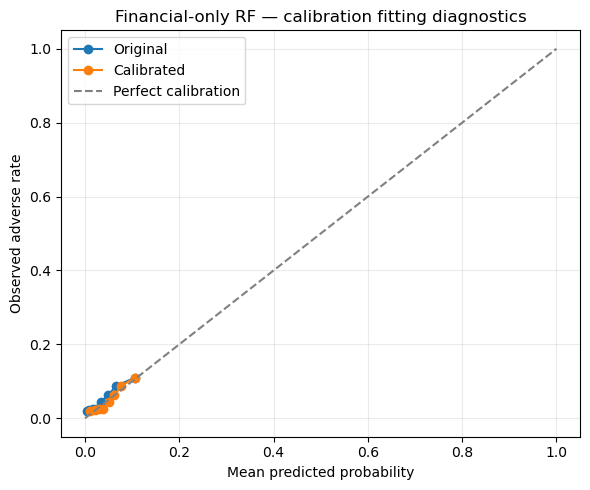


These are fitting diagnostics, not independent evaluation.


In [26]:
# TASK 1.5E — Calibrate the financial-only Random Forest

print("TASK 1.5E: Financial-only Random Forest calibration")

def financial_log_odds(probabilities):
    p = np.clip(np.asarray(probabilities), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p)).reshape(-1, 1)

# rf_pipeline remains fitted on training data only.
# Fit the probability mapping using validation data.
rf_financial_calibrator = LogisticRegression(
    C=1e6,
    solver="lbfgs",
    max_iter=1000,
    class_weight=None,
    random_state=RANDOM_SEED
)

rf_financial_calibrator.fit(
    financial_log_odds(rf_val_proba),
    y_val
)

assert rf_financial_calibrator.coef_[0, 0] > 0, \
    "Calibration reversed the ranking; investigate before proceeding."

rf_val_calibrated = rf_financial_calibrator.predict_proba(
    financial_log_odds(rf_val_proba)
)[:, 1]

print("\nCalibration fitting diagnostics:")
print(f"Observed adverse rate: {y_val.mean():.2%}")
print(f"Original mean probability: {rf_val_proba.mean():.2%}")
print(f"Calibrated mean probability: {rf_val_calibrated.mean():.2%}")
print(
    f"Original Brier score: "
    f"{brier_score_loss(y_val, rf_val_proba):.4f}"
)
print(
    f"Calibrated Brier score: "
    f"{brier_score_loss(y_val, rf_val_calibrated):.4f}"
)

fig_rf_cal, ax_rf_cal = plt.subplots(figsize=(6, 5))

for label, probabilities in [
    ("Original", rf_val_proba),
    ("Calibrated", rf_val_calibrated)
]:
    observed, predicted = calibration_curve(
        y_val,
        probabilities,
        n_bins=8,
        strategy="quantile"
    )
    ax_rf_cal.plot(predicted, observed, marker="o", label=label)

ax_rf_cal.plot(
    [0, 1], [0, 1],
    "--", color="gray", label="Perfect calibration"
)
ax_rf_cal.set_xlabel("Mean predicted probability")
ax_rf_cal.set_ylabel("Observed adverse rate")
ax_rf_cal.set_title("Financial-only RF — calibration fitting diagnostics")
ax_rf_cal.legend()
ax_rf_cal.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("\nThese are fitting diagnostics, not independent evaluation.")

TASK 1.5F: Financial-only Random Forest test evaluation

Test rows: 15,536
Adverse outcomes: 628
Observed adverse rate: 4.04%

Financial-only test results:
                    model  ROC_AUC   PR_AUC    Brier  mean_probability
  Random Forest: original 0.688273 0.095044 0.037988          0.035844
Random Forest: calibrated 0.688273 0.095044 0.038059          0.047521

Training-prevalence constant Brier score: 0.038817


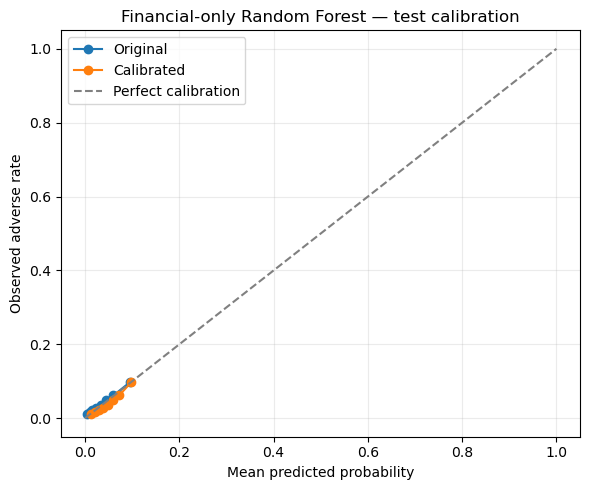


This test period was previously examined in the opinion-history experiment.


In [27]:
# TASK 1.5F — Financial-only Random Forest test evaluation

print("TASK 1.5F: Financial-only Random Forest test evaluation")

# Use only the 19 financial features.
rf_financial_test_raw = rf_pipeline.predict_proba(
    X_test_feat[feature_cols]
)[:, 1]

rf_financial_test_calibrated = (
    rf_financial_calibrator.predict_proba(
        financial_log_odds(rf_financial_test_raw)
    )[:, 1]
)

financial_test_results = []

for name, probabilities in [
    ("Random Forest: original", rf_financial_test_raw),
    ("Random Forest: calibrated", rf_financial_test_calibrated)
]:
    precision, recall, _ = precision_recall_curve(
        y_test, probabilities
    )

    financial_test_results.append({
        "model": name,
        "ROC_AUC": roc_auc_score(y_test, probabilities),
        "PR_AUC": auc(recall, precision),
        "Brier": brier_score_loss(y_test, probabilities),
        "mean_probability": probabilities.mean()
    })

financial_test_comparison = pd.DataFrame(financial_test_results)

print(f"\nTest rows: {len(y_test):,}")
print(f"Adverse outcomes: {y_test.sum():,}")
print(f"Observed adverse rate: {y_test.mean():.2%}")

print("\nFinancial-only test results:")
print(
    financial_test_comparison.round(6).to_string(index=False)
)

constant_test_probability = np.full(len(y_test), y_train.mean())

print(
    f"\nTraining-prevalence constant Brier score: "
    f"{brier_score_loss(y_test, constant_test_probability):.6f}"
)

# Plot calibration on the test period
fig_rf_test, ax_rf_test = plt.subplots(figsize=(6, 5))

for label, probabilities in [
    ("Original", rf_financial_test_raw),
    ("Calibrated", rf_financial_test_calibrated)
]:
    observed, predicted = calibration_curve(
        y_test,
        probabilities,
        n_bins=8,
        strategy="quantile"
    )
    ax_rf_test.plot(predicted, observed, marker="o", label=label)

ax_rf_test.plot(
    [0, 1], [0, 1],
    "--", color="gray", label="Perfect calibration"
)
ax_rf_test.set_xlabel("Mean predicted probability")
ax_rf_test.set_ylabel("Observed adverse rate")
ax_rf_test.set_title("Financial-only Random Forest — test calibration")
ax_rf_test.legend()
ax_rf_test.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(
    "\nThis test period was previously examined "
    "in the opinion-history experiment."
)

In [28]:
# TASK 1.6A — Freeze the financial-only model and write its model card

import hashlib
import json
import platform
import sklearn
from datetime import timezone

print("TASK 1.6A: Freeze financial-only Random Forest v1")

models_dir = Path("models")
results_dir = Path("results")

models_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

frozen_at = datetime.now(timezone.utc).isoformat()

# Identify the exact source dataset
source_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()

# Record actual retained periods, rather than planned periods
def summarize_split(frame):
    return {
        "rows": int(len(frame)),
        "feature_year_min": int(frame["feature_year"].min()),
        "feature_year_max": int(frame["feature_year"].max()),
        "outcome_year_min": int(frame["outcome_year"].min()),
        "outcome_year_max": int(frame["outcome_year"].max()),
        "adverse_outcomes": int(frame["target"].sum()),
        "adverse_rate": float(frame["target"].mean())
    }

split_summary = {
    "training": summarize_split(X_train),
    "validation": summarize_split(X_val),
    "test": summarize_split(X_test)
}

# Save only the selected financial-only model objects.
# Keep calibrated probabilities as the default chosen before test evaluation.
model_data = {
    "model_version": "financial_only_rf_v1",
    "pipeline": rf_pipeline,
    "calibrator": rf_financial_calibrator,
    "feature_cols": feature_cols.copy(),
    "default_probability": "calibrated",
    "calibration_transform": {
        "method": "sigmoid applied to log-odds",
        "clip_min": 1e-6,
        "clip_max": 1 - 1e-6
    },
    "target_definition": "Fiscal-year t+1 auopic equals 2",
    "timing_decision": timing_decision,
    "feature_decision": feature_decision,
    "split_summary": split_summary,
    "source_file": DATA_PATH.name,
    "source_sha256": source_hash,
    "random_seed": RANDOM_SEED,
    "test_results": financial_test_comparison.to_dict("records"),
    "frozen_at_utc": frozen_at,
    "versions": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__
    }
}

model_path = models_dir / "financial_only_rf_v1.pkl"

with model_path.open("wb") as f:
    pickle.dump(model_data, f, protocol=pickle.HIGHEST_PROTOCOL)

# Check that loading reproduces the stored test probabilities
with model_path.open("rb") as f:
    loaded_model = pickle.load(f)

reloaded_raw = loaded_model["pipeline"].predict_proba(
    X_test_feat[loaded_model["feature_cols"]]
)[:, 1]

clipped = np.clip(reloaded_raw, 1e-6, 1 - 1e-6)
reloaded_log_odds = np.log(
    clipped / (1 - clipped)
).reshape(-1, 1)

reloaded_calibrated = loaded_model["calibrator"].predict_proba(
    reloaded_log_odds
)[:, 1]

np.testing.assert_allclose(
    reloaded_raw, rf_financial_test_raw,
    rtol=1e-12, atol=1e-12
)
np.testing.assert_allclose(
    reloaded_calibrated, rf_financial_test_calibrated,
    rtol=1e-12, atol=1e-12
)

# Save comparison tables and decisions
validation_comparison.to_csv(
    results_dir / "financial_only_validation_metrics.csv",
    index=False
)
financial_test_comparison.to_csv(
    results_dir / "financial_only_test_metrics.csv",
    index=False
)

decisions_path = models_dir / "financial_only_decisions.json"
decisions_path.write_text(
    json.dumps({
        "timing": timing_decision,
        "features": feature_decision,
        "actual_splits": split_summary
    }, indent=2),
    encoding="utf-8"
)

# Build the model card using actual run values
split_lines = []
for name, info in split_summary.items():
    split_lines.append(
        f"- {name.title()}: {info['rows']:,} rows; "
        f"feature years {info['feature_year_min']}–"
        f"{info['feature_year_max']}; "
        f"outcome years {info['outcome_year_min']}–"
        f"{info['outcome_year_max']}; "
        f"adverse rate {info['adverse_rate']:.2%}."
    )

metric_lines = [
    "| Version | ROC-AUC | PR-AUC | Brier | Mean probability |",
    "|---|---:|---:|---:|---:|"
]

for result in financial_test_comparison.to_dict("records"):
    metric_lines.append(
        f"| {result['model']} | {result['ROC_AUC']:.6f} "
        f"| {result['PR_AUC']:.6f} | {result['Brier']:.6f} "
        f"| {result['mean_probability']:.2%} |"
    )

model_card = f"""# Financial Only Auditor Opinion Forecast Model v1

Frozen at UTC: {frozen_at}

Status: Experimental capstone model. The project ROC-AUC target of .826
has not been achieved. This next-year forecasting specification differs
from the project plan's reference experiment.

## Prediction task

Use fiscal-year t financial features to forecast an adverse internal-control
opinion in fiscal year t+1. This predicts an internal-control risk indicator,
not confirmed fraud.

Both years are restricted to auopic codes 1 and 2.
Matching requires the exact company and following fiscal year.

## Model and preprocessing

- Algorithm: Random Forest.
- Parameters: {rf_pipeline.named_steps['classifier'].get_params()}
- Financial predictors: {len(feature_cols)}.
- Predictor names: {', '.join(feature_cols)}.
- No control-opinion history or SIC predictor is included.
- Original unsuffixed financial columns are used.
- CFsale = oibdp / sale; zero sales and infinite values become missing.
- DPR and INV_TURN are retained.
- Median imputation and missing indicators are fitted on training data only.
- No additional percentile clipping is applied.
- Calibration: sigmoid mapping of log-odds fitted on validation data.
- Default scoring output: calibrated probability, with original probability
  also available.

## Actual data splits

{chr(10).join(split_lines)}

Boundary rows were excluded when their outcome INFO_DATE did not precede
the next period's earliest prediction date.

## Model selection

Financial-only logistic regression, Random Forest and XGBoost were
compared on validation data. Random Forest led the initial comparison
on ROC-AUC, PR-AUC and Brier score.

Validation data were also used to fit calibration. Calibration-set
diagnostics are therefore fitting results, not independent evaluation.

## Test results

{chr(10).join(metric_lines)}

Observed test adverse rate: {y_test.mean():.2%}.

Calibration increased average test risk and slightly worsened the Brier
score. Both probability versions are retained; the default is not changed
using test results.

## Limitations and remaining checks

- INFO_DATE is an availability proxy, not a verified publication date.
- The test period was previously examined in the opinion-history experiment.
- Firms may appear in multiple periods; this assesses future observations,
  not exclusively unseen firms.
- Performance does not directly reproduce the plan's .826 reference.
- No operational classification threshold has been selected.
- score_firm implementation and interface review remain pending.
- Teammate clean-run reproduction and second-seed sensitivity remain pending.

## Reproducibility

Source file: {DATA_PATH.name}
Source SHA256: {source_hash}
Random seed: {RANDOM_SEED}
Environment versions: {model_data['versions']}

The saved artifact contains the fitted imputation pipeline, classifier,
calibrator, ordered feature list and timing decisions.
Reloaded predictions were checked against this notebook's test predictions.
"""

card_path = models_dir / "financial_only_rf_v1_model_card.md"
card_path.write_text(model_card, encoding="utf-8")

print("\nSaved and verified:")
for path in [model_path, card_path, decisions_path]:
    print(path.resolve())

print("\nReloaded original and calibrated predictions match.")
print("Task 1.6A complete. score_firm() remains for Task 1.6B.")

TASK 1.6A: Freeze financial-only Random Forest v1

Saved and verified:
/Users/jessica/Desktop/ADV ML Group work/models/financial_only_rf_v1.pkl
/Users/jessica/Desktop/ADV ML Group work/models/financial_only_rf_v1_model_card.md
/Users/jessica/Desktop/ADV ML Group work/models/financial_only_decisions.json

Reloaded original and calibrated predictions match.
Task 1.6A complete. score_firm() remains for Task 1.6B.


In [29]:
%%writefile scoring.py
import numpy as np
import pandas as pd


def score_firm(gvkey, feature_year, panel, artifact):
    """
    Score a firm using fiscal-year t financial features.
    Forecast: adverse internal-control opinion in fiscal year t+1.

    Rank is a retrospective comparison among assessed firms in year t.
    """
    cols = artifact["feature_cols"]
    year = int(feature_year)

    # Normalize the numeric Compustat identifier for matching.
    def normalize_gvkey(value):
        text = str(value).strip()
        if text.endswith(".0"):
            text = text[:-2]
        return text.lstrip("0") or "0"

    cohort = panel.loc[
        panel["fyear"].eq(year) & panel["auopic"].isin([1, 2])
    ].copy()

    if cohort.empty:
        raise ValueError(f"No assessed firms available for FY{year}.")

    if cohort["gvkey"].isna().any():
        raise ValueError("Missing firm identifiers in the cohort.")

    cohort["_firm_key"] = cohort["gvkey"].map(normalize_gvkey)

    if cohort["_firm_key"].duplicated().any():
        raise ValueError("Duplicate firm-year identifiers.")

    requested_key = normalize_gvkey(gvkey)
    selected = cohort["_firm_key"].eq(requested_key)

    if selected.sum() != 1:
        raise ValueError(
            f"Expected one assessed record for gvkey={gvkey}, FY{year}; "
            f"found {selected.sum()}."
        )

    # Apply the same deterministic feature preparation as Task 1.3.
    sales = pd.to_numeric(cohort["sale"], errors="raise")
    income = pd.to_numeric(cohort["oibdp"], errors="raise")
    cohort["cfsale"] = income / sales.replace(0, np.nan)

    features = (
        cohort[cols]
        .apply(pd.to_numeric, errors="raise")
        .replace([np.inf, -np.inf], np.nan)
    )

    # Saved pipeline applies training-fitted imputation.
    raw = artifact["pipeline"].predict_proba(features)[:, 1]

    settings = artifact["calibration_transform"]
    clipped = np.clip(
        raw, settings["clip_min"], settings["clip_max"]
    )
    log_odds = np.log(clipped / (1 - clipped)).reshape(-1, 1)

    calibrated = artifact["calibrator"].predict_proba(log_odds)[:, 1]

    version = artifact["default_probability"]
    if version not in {"original", "calibrated"}:
        raise ValueError("Unknown default probability version.")

    probability = calibrated if version == "calibrated" else raw

    # Ties share the best occupied rank.
    ranks = pd.Series(probability).rank(
        ascending=False, method="min"
    ).astype(int).to_numpy()

    position = int(np.flatnonzero(selected.to_numpy())[0])
    row = cohort.iloc[position]
    missing_features = features.columns[
        features.iloc[position].isna()
    ].tolist()

    return {
        "gvkey": str(row["gvkey"]),
        "feature_year": year,
        "outcome_year": year + 1,
        "prediction_date": pd.Timestamp(row["INFO_DATE"]).isoformat(),
        "probability": float(probability[position]),
        "probability_version": version,
        "probability_original": float(raw[position]),
        "probability_calibrated": float(calibrated[position]),
        "risk_rank": int(ranks[position]),
        "cohort_size": int(len(cohort)),
        "rank_definition": (
            "Descending risk; 1 is highest; ties use minimum rank."
        ),
        "cohort_definition": (
            "All panel firms with auopic 1 or 2 in the feature year."
        ),
        "missing_features_imputed": missing_features,
        "model_version": artifact["model_version"],
        "source": (
            f"{artifact['source_file']}; "
            f"sha256={artifact['source_sha256']}; "
            f"gvkey={row['gvkey']}; fyear={year}; "
            f"predictors={','.join(cols)}; "
            f"cfsale=oibdp/sale"
        ),
        "interpretation": (
            "Retrospective score using the frozen model. "
            "Year-wide rank is not an as-of-date live ranking."
        )
    }

Writing scoring.py


In [30]:
# TASK 1.6B — Load and verify score_firm()
import importlib
import scoring

importlib.reload(scoring)

with model_path.open("rb") as f:
    scoring_artifact = pickle.load(f)

# Verify the panel matches the source recorded in the artifact.
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest() == \
    scoring_artifact["source_sha256"], "Source dataset has changed."

example = X_test.iloc[0]

result = scoring.score_firm(
    gvkey=example["gvkey"],
    feature_year=example["feature_year"],
    panel=df_raw,
    artifact=scoring_artifact
)

# Match the same observation scored during final test evaluation.
np.testing.assert_allclose(
    result["probability_original"],
    rf_financial_test_raw[0],
    rtol=1e-12,
    atol=1e-12
)
np.testing.assert_allclose(
    result["probability_calibrated"],
    rf_financial_test_calibrated[0],
    rtol=1e-12,
    atol=1e-12
)

print(json.dumps(result, indent=2))
print("\nScoring probabilities match the test evaluation.")
print(f"Scoring module saved at: {Path('scoring.py').resolve()}")

{
  "gvkey": "001094",
  "feature_year": 2017,
  "outcome_year": 2018,
  "prediction_date": "2017-09-30T00:00:00",
  "probability": 0.07655706968638816,
  "probability_version": "calibrated",
  "probability_original": 0.0653746881451259,
  "probability_calibrated": 0.07655706968638816,
  "risk_rank": 532,
  "cohort_size": 3468,
  "rank_definition": "Descending risk; 1 is highest; ties use minimum rank.",
  "cohort_definition": "All panel firms with auopic 1 or 2 in the feature year.",
  "missing_features_imputed": [],
  "model_version": "financial_only_rf_v1",
  "source": "final_panel.csv; sha256=482b5947612a99a6e3d9c0e5d09f781442967bf2d1f209db8ff48add16aac788; gvkey=001094; fyear=2017; predictors=LNEMP,LNTA,LNSALE,LNTI,IntanTA,InvCA,CapInt,TobinQ,RET1Y,ROA,ROE,GPM,CURR_RATIO,AT_TURN,INV_TURN,DPR,PTB,PE,cfsale; cfsale=oibdp/sale",
  "interpretation": "Retrospective score using the frozen model. Year-wide rank is not an as-of-date live ranking."
}

Scoring probabilities match the test e

In [31]:
# TASK 1.6C — Record scoring verification

verification_path = results_dir / "score_firm_verification.json"
verification_path.write_text(
    json.dumps(result, indent=2),
    encoding="utf-8"
)

card_text = card_path.read_text(encoding="utf-8")

card_text = card_text.replace(
    "- score_firm implementation and interface review remain pending.",
    "- score_firm is implemented in scoring.py. Original and calibrated "
    "probabilities matched the test evaluation for one checked firm-year. "
    "Team tool-contract review remains pending."
)

card_path.write_text(card_text, encoding="utf-8")

print(f"Verification saved: {verification_path.resolve()}")
print(f"Model card updated: {card_path.resolve()}")

Verification saved: /Users/jessica/Desktop/ADV ML Group work/results/score_firm_verification.json
Model card updated: /Users/jessica/Desktop/ADV ML Group work/models/financial_only_rf_v1_model_card.md
